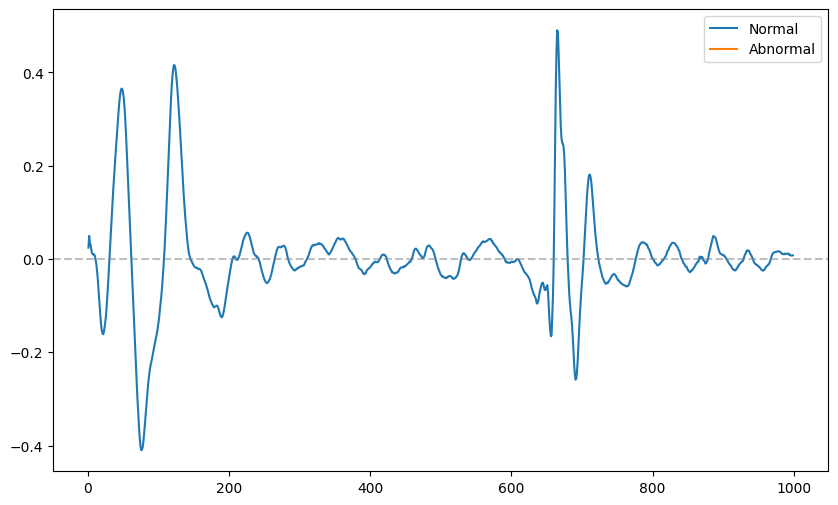

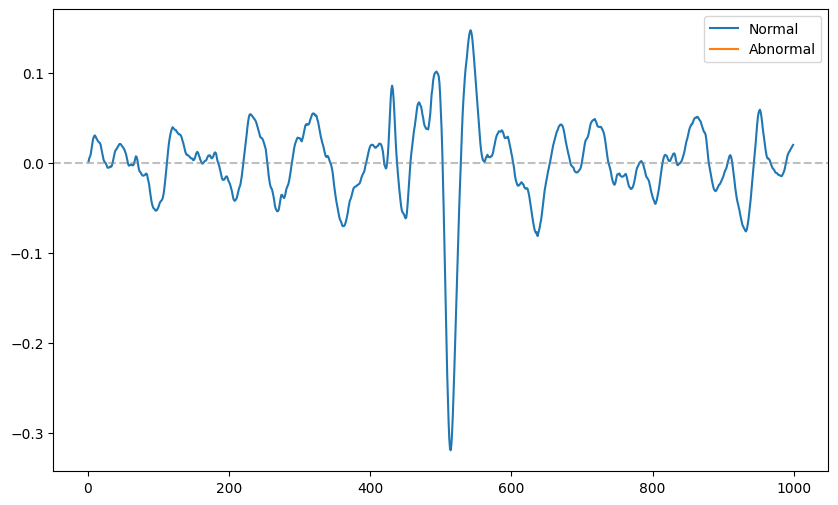

In [3]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import numpy as np
## Read in data
arff_file_train = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
df_train = pd.DataFrame(arff_file_train[0])

def plot_heartbeats(start, end, df):
    """
    Plots rows of the original dataframe from start (inclusive) to end (exclusive).
    This plots first 1000 amplitudes of abnormal and normal people separately
    """
    patients = sorted(df['patient_number'].unique())

    for p in patients[start:end]:
        patient_df = df[df['patient_number'] == p]
        patient_df = patient_df[patient_df['att'] < 1000]
        abnormal_df = patient_df[patient_df['target'] == 'Abnormal']
        normal_df = patient_df[patient_df['target'] == 'Normal']
        plt.figure(figsize=(10, 6))
        plt.plot(normal_df['att'], normal_df['amplitude'], label='Normal')
        plt.plot(abnormal_df['att'], abnormal_df['amplitude'], label='Abnormal')
        plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
        plt.legend()
        plt.show()

def eda(df):
    df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
    last_row_target = df['target']
    df.drop('target', axis=1, inplace=True)
    df1 = df.stack(future_stack=True).reset_index()
    df1.drop('level_0', axis=1, inplace=True)
    df1['target'] = np.repeat(np.asarray(last_row_target), 18530)
    df1["patient_number"] = df1.index // 18530 + 1
    df1.rename(columns={'level_1': 'att', 0: 'amplitude'}, inplace=True)
    df1['att'] = df1['att'].str.replace('att', '', regex=False).astype(int)
    return df1

df_train = eda(df_train)
plot_heartbeats(202, 204, df_train)

### flaviagiammarino InceptionTime

#### Preprocessing

In [4]:
# From your ARFF preprocessing, e.g. similar to what you already have
# x_train, y_train, x_test, y_test are pandas objects
df = pd.DataFrame(arff_file_train[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df['target'] = df['target'].map({'Abnormal': 1, 'Normal': 0})
x_train = df.drop('target', axis=1)
y_train = df['target']

x_train_full = x_train.to_numpy().astype(np.float32)  # (n_train_patients, 18530)
y_train_full = y_train.to_numpy().astype(np.int64)    # (n_train_patients,)

#### Model Training

In [ ]:
from inception_time_pytorch.model import InceptionTime
import torch

model = InceptionTime(
    # I tried a rolling window approach here but couldn't seem to figure it out
    x=x_train_win,
    y=y_train_win,
    filters=32,
    depth=6,
    models=1,
)

model.fit(
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
    verbose=True,
)


Training model 1 on cpu.
epoch: 1, loss: 0.391613, accuracy: 0.833333
epoch: 2, loss: 0.484801, accuracy: 0.777778
epoch: 3, loss: 0.537339, accuracy: 0.722222
epoch: 4, loss: 0.296272, accuracy: 0.916667
epoch: 5, loss: 0.625530, accuracy: 0.694444
epoch: 6, loss: 0.410773, accuracy: 0.833333
epoch: 7, loss: 0.569735, accuracy: 0.722222
epoch: 8, loss: 0.250702, accuracy: 0.972222
epoch: 9, loss: 0.353924, accuracy: 0.861111
epoch: 10, loss: 0.393049, accuracy: 0.777778
-----------------------------------------
Training model 2 on cpu.


KeyboardInterrupt: 

## Code we might not wanna throw

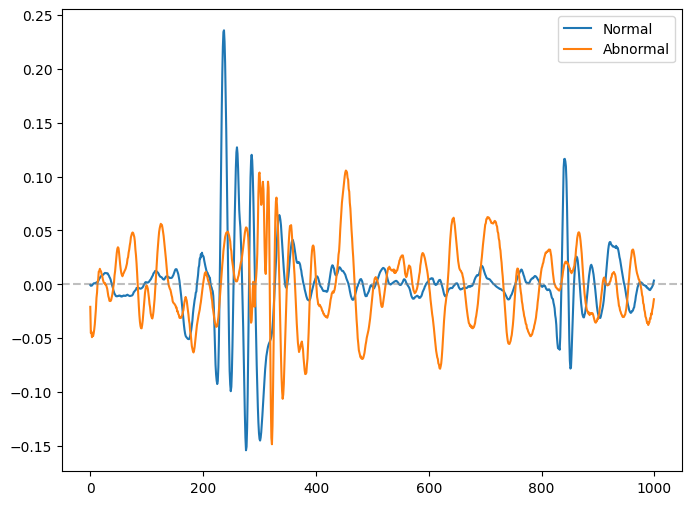

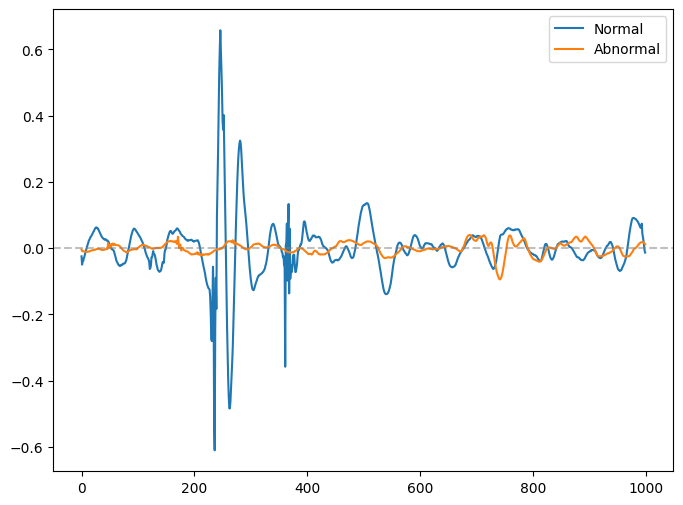

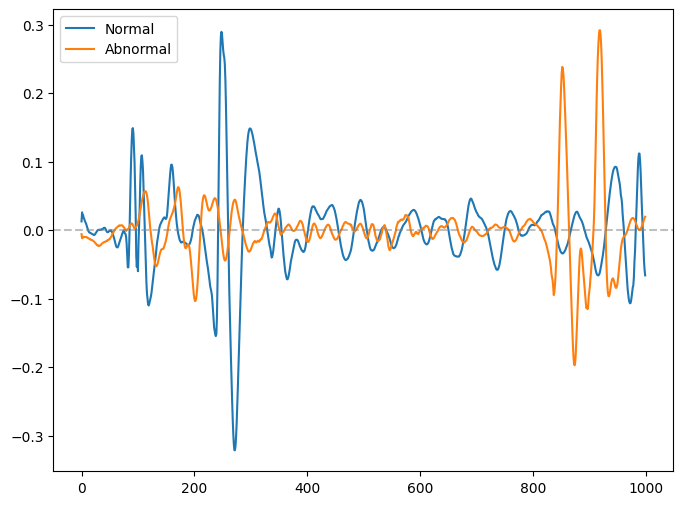

In [ ]:
# NOTE: Keeping this here in case we want to look at it again. This plots the first 1000 timestamps 
# of amplitudes of first 3 normal and abnormal patients
arff_file = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
df = pd.DataFrame(arff_file[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
abnormal = df.loc[df['target'] == 'Abnormal']
normal = df.loc[df['target'] == 'Normal']
for i in range(3):
    ab_x_first = abnormal.select_dtypes(include=['number']).T.iloc[:,i]
    n_x_first = normal.select_dtypes(include=['number']).T.iloc[:,i]
    plt.figure(figsize=(8,6))
    plt.plot(range(len(n_x_first))[0:1000], n_x_first[0:1000], label = 'Normal')
    plt.plot(range(len(ab_x_first))[0:1000], ab_x_first[0:1000], label = 'Abnormal')
    plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
    plt.legend()
    plt.show()

In [7]:
# train imbalance
cb_train = df_train.value_counts('target')/len(df_train)
cb_train

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64

In [8]:
# load train set
arff_file = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
test = pd.DataFrame(arff_file[0])
test['target'] = test['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')

# test class imbalance
cb_test = test.value_counts('target')/len(df)
cb_test

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64

In [9]:
# overall class imbalance
(cb_train + cb_test)/2

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64